
# Machine Learning con Python
### Webinar Gratuito
## Quantmetrics
# !Impulsa tu futuro con el poder Quant!
## Docente: Jean Taipe

---

## Objetivo del Proyecto

Desarrollar un modelo de Machine Learning capaz de predecir el **costo esperado de siniestros médicos** para un asegurado, utilizando variables demográficas y características de póliza.

---

## Problema de Negocio

Las aseguradoras necesitan:

- Estimar el costo esperado antes de emitir una póliza.
- Ajustar primas según riesgo.
- Detectar perfiles de alto costo.
- Optimizar rentabilidad y solvencia.

Formalmente:

$$
Y = f(X) + \epsilon
$$

Donde:

- $(Y$): Costo de siniestros.
- $(X$): Variables del asegurado.
- $(\epsilon$): Error aleatorio.

---


## 🌳 Representación Conceptual del Árbol de Decisión


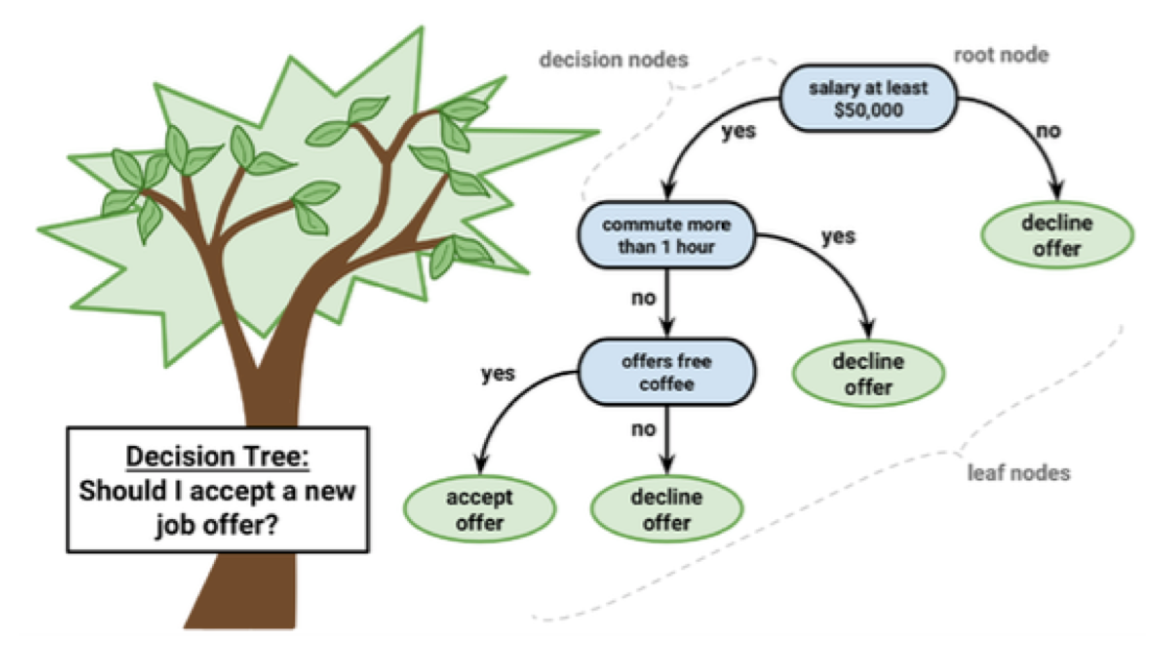

In [2]:
from IPython.display import Image
Image("arbol.png")

# 🌳 Árbol de Decisión para Predicción de Costos de Salud

## Idea Intuitiva

Un Árbol de Decisión divide el espacio de variables en regiones usando reglas del tipo:

- age < 45
- chronic_condition = 1
- sum_insured > 100000

Cada división busca reducir la variabilidad del costo dentro de cada grupo.

En cada hoja del árbol, la predicción es:

$$
\hat{y} = \text{Promedio de los costos en esa región}
$$

---

## Fundamento Matemático

El árbol elige divisiones que minimizan el **Error Cuadrático Medio (MSE)**:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n}(y_i - \bar{y}_{region})^2
$$

En cada posible partición, el algoritmo busca:

$$
\min_{split} \left( \sum_{i \in R_1}(y_i - \bar{y}_{R_1})^2 +
\sum_{i \in R_2}(y_i - \bar{y}_{R_2})^2 \right)
$$

Donde:

- $(R_1, R_2$) son las regiones generadas por la división.
- $(\bar{y}_{R}$) es el promedio del costo en esa región.

---

## Interpretación en Seguros

Un árbol puede generar reglas como:

Si:
- Edad > 60
- Tiene condición crónica
- Suma asegurada alta

Entonces:
$$
\hat{Costo} \approx 45,000
$$

Esto es extremadamente útil para:

- Segmentación de riesgo
- Pricing actuarial
- Identificación de perfiles costosos

---

## Ventajas y Desventajas

| Ventajas | Desventajas |
|----------|------------|
| Fácil de interpretar | Puede sobreajustar |
| No requiere escalamiento | Alta varianza |
| Captura relaciones no lineales | Sensible a cambios pequeños en datos |

---

## Problema: Alta Varianza

Un árbol profundo puede memorizar los datos:

$$
\text{Overfitting}
$$

Por eso se controla con:

- `max_depth`
- `min_samples_leaf`
- `min_samples_split`

---

## Conclusión

El Árbol de Decisión es:

✔ Interpretativo  
✔ Ideal como primer modelo no lineal  
✔ Muy didáctico para explicar segmentación de riesgo  

# 🌲 Random Forest para Predicción de Costos de Salud

## Motivación

Un solo árbol puede tener alta varianza.

Solución: combinar muchos árboles.

Random Forest construye múltiples árboles sobre muestras aleatorias del dataset y luego promedia sus predicciones.

---

## Idea Matemática

Si tenemos $(T$) árboles:

$$
\hat{y}(x) = \frac{1}{T} \sum_{t=1}^{T} h_t(x)
$$

Donde:

- $(h_t(x)$) = predicción del árbol t
- $(T$) = número total de árboles

---

## ¿Por qué funciona mejor?

Cada árbol se entrena con:

1. Muestras bootstrap (subconjuntos aleatorios)
2. Subconjuntos aleatorios de variables

Esto reduce la correlación entre árboles.

---

## Reducción de Varianza

Si cada árbol tiene varianza $( \sigma^2 $), al promediarlos:

$$
Var(\hat{y}) \approx \frac{\sigma^2}{T}
$$

(aproximadamente si los árboles no están perfectamente correlacionados)

Esto hace el modelo mucho más estable.

---

## Interpretación en Seguros

Random Forest permite:

- Capturar interacciones complejas (edad + condición + región)
- Modelar efectos no lineales
- Mejorar precisión sin perder demasiada interpretabilidad

Ejemplo:

- Edad impacta diferente según presencia de enfermedad crónica
- Suma asegurada amplifica efecto de edad

---

## Feature Importance

Random Forest permite medir importancia de variables:

$$
Importance_j = \text{Reducción promedio del error causada por la variable j}
$$

Esto es muy útil para:

- Identificar drivers de costo
- Justificar ajustes de prima
- Explicar resultados a directivos

---

## Comparación Árbol vs Random Forest

| Característica | Árbol | Random Forest |
|---------------|--------|---------------|
| Interpretabilidad | Alta | Media |
| Precisión | Media | Alta |
| Varianza | Alta | Baja |
| Riesgo de overfitting | Alto | Bajo |

---

## Conclusión

Random Forest es:

✔ Más robusto  
✔ Mejor capacidad predictiva  
✔ Ideal para problemas reales de pricing  

En seguros de salud suele mejorar significativamente el R² respecto a un árbol simple.

---

## Métrica Principal

Error Cuadrático Medio:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Raíz del MSE (RMSE):

$$
RMSE = \sqrt{MSE}
$$


## Importación de Librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

import plotly.express as px


## Importación de datos


In [4]:
df = pd.read_excel('bd_salud_coste.xlsx')
df

,Unnamed: 0,age,gender,region,policy_type,sum_insured,chronic_condition,claims_amount
0,0,53,Male,South,Gold,200000,0,24827.206761
1,1,70,Male,South,Gold,50000,0,18577.501585
2,2,45,Male,North,Premium,100000,0,10464.532684
3,3,58,Male,North,Premium,200000,0,16519.413382
4,4,24,Male,South,Gold,100000,0,7585.486827
...,...,...,...,...,...,...,...,...
9995,9995,65,Male,West,Gold,200000,0,21152.779839
9996,9996,63,Female,North,Basic,100000,0,2291.707770
9997,9997,50,Female,South,Basic,200000,0,16867.529550
9998,9998,65,Female,North,Basic,200000,0,5018.343615


## Análisis Exploratorio

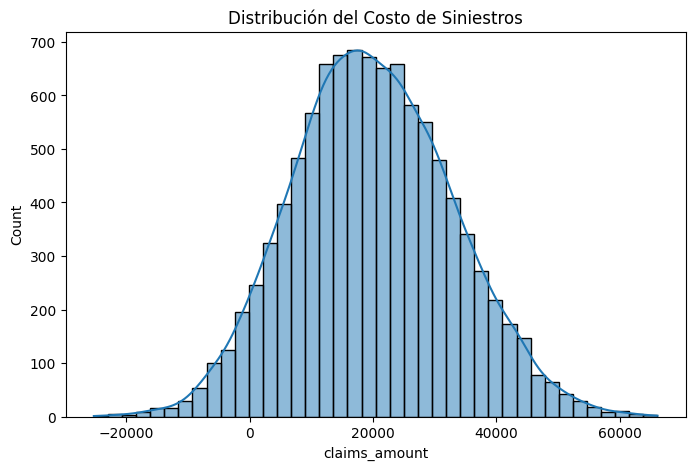

In [5]:

plt.figure(figsize=(8,5))
sns.histplot(df["claims_amount"], bins=40, kde=True)
plt.title("Distribución del Costo de Siniestros")
plt.show()


## Preprocesamiento

In [6]:

X = df.drop("claims_amount", axis=1)
y = df["claims_amount"]

cat_vars = ["gender", "region", "policy_type"]
num_vars = ["age", "sum_insured", "chronic_condition"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_vars)
], remainder="passthrough")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
X_train

,Unnamed: 0,age,gender,region,policy_type,sum_insured,chronic_condition
9254,9254,62,Male,South,Premium,50000,0
1561,1561,72,Male,West,Gold,50000,0
1670,1670,74,Female,West,Gold,100000,0
6087,6087,26,Male,West,Basic,100000,0
6669,6669,73,Male,East,Premium,50000,0
...,...,...,...,...,...,...,...
5734,5734,33,Female,East,Gold,100000,1
5191,5191,39,Female,South,Basic,100000,0
5390,5390,45,Male,South,Premium,100000,0
860,860,60,Female,West,Gold,100000,0


In [8]:
X_test

,Unnamed: 0,age,gender,region,policy_type,sum_insured,chronic_condition
6252,6252,38,Male,West,Gold,200000,0
4684,4684,62,Male,North,Basic,100000,0
1731,1731,64,Male,East,Premium,200000,0
4742,4742,65,Male,West,Premium,50000,0
4521,4521,42,Male,East,Basic,50000,0
...,...,...,...,...,...,...,...
6412,6412,49,Female,East,Gold,200000,0
8285,8285,71,Female,West,Premium,100000,1
7853,7853,50,Female,West,Gold,100000,0
1095,1095,33,Female,North,Gold,100000,0


In [9]:
y_train

,claims_amount
9254,17626.836228
1561,9848.068142
1670,8755.629422
6087,4665.613651
6669,18367.901305
...,...
5734,12616.303962
5191,17184.468359
5390,31101.519906
860,19285.242490


In [10]:
y_test

,claims_amount
6252,15457.020288
4684,14569.471007
1731,17778.473870
4742,19245.085837
4521,22183.597449
...,...
6412,12955.178731
8285,45929.996728
7853,6747.568381
1095,24827.213783


## Modelamiento

In [11]:
# Arbol de Decisión
from sklearn.tree import DecisionTreeRegressor

tree_model = Pipeline([
    ("prep", preprocess),
    ("tree", DecisionTreeRegressor(
        max_depth=5,          # Controla complejidad
        min_samples_leaf=50,  # Evita sobreajuste
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_pred_tree


array([17818.5448949 , 15971.1368871 , 20291.91580765, ...,
       14921.73103057, 11741.74029684, 17732.01200238])

In [12]:
y_test

,claims_amount
6252,15457.020288
4684,14569.471007
1731,17778.473870
4742,19245.085837
4521,22183.597449
...,...
6412,12955.178731
8285,45929.996728
7853,6747.568381
1095,24827.213783


In [13]:
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("ÁRBOL")
print("RMSE:", rmse_tree)
print("R2:", r2_tree)

ÁRBOL
RMSE: 10085.66959021344
R2: 0.3984216617028148


In [14]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("prep", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_rf


array([16519.19594781, 15240.4508016 , 21323.37972495, ...,
       15486.88511455, 10242.85146787, 16333.48383533])

In [15]:
y_test

,claims_amount
6252,15457.020288
4684,14569.471007
1731,17778.473870
4742,19245.085837
4521,22183.597449
...,...
6412,12955.178731
8285,45929.996728
7853,6747.568381
1095,24827.213783


In [16]:

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRANDOM FOREST")
print("RMSE:", rmse_rf)
print("R2:", r2_rf)


RANDOM FOREST
RMSE: 10076.318764296397
R2: 0.39953663906112336


In [17]:
results = pd.DataFrame({
    "Modelo": ["Decision Tree", "Random Forest"],
    "RMSE": [rmse_tree, rmse_rf],
    "R2": [r2_tree, r2_rf]
})

results

,Modelo,RMSE,R2
0,Decision Tree,10085.669590,0.398422
1,Random Forest,10076.318764,0.399537


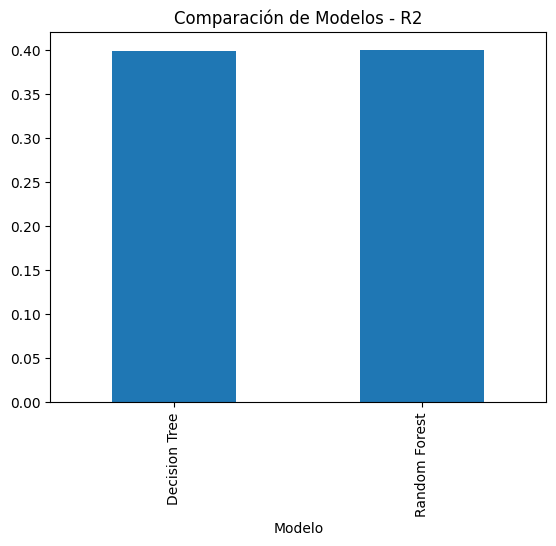

In [18]:
results.set_index("Modelo")["R2"].plot(kind="bar")
plt.title("Comparación de Modelos - R2")
plt.show()

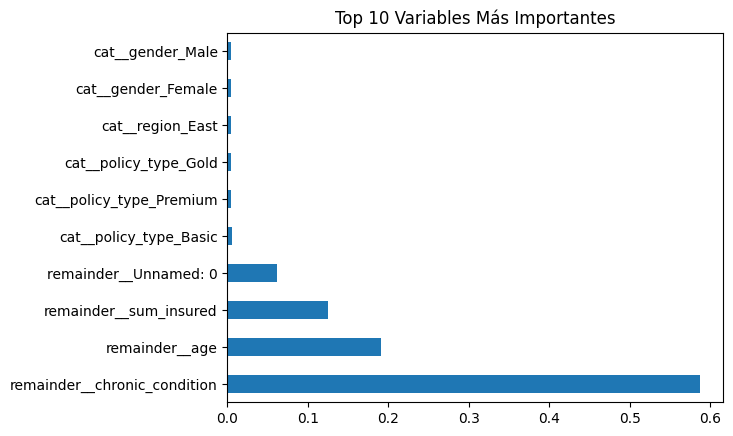

In [19]:
#Importancia de variables
importances = rf_model.named_steps["rf"].feature_importances_

feature_names = rf_model.named_steps["prep"].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.head(10).plot(kind="barh")
plt.title("Top 10 Variables Más Importantes")
plt.show()

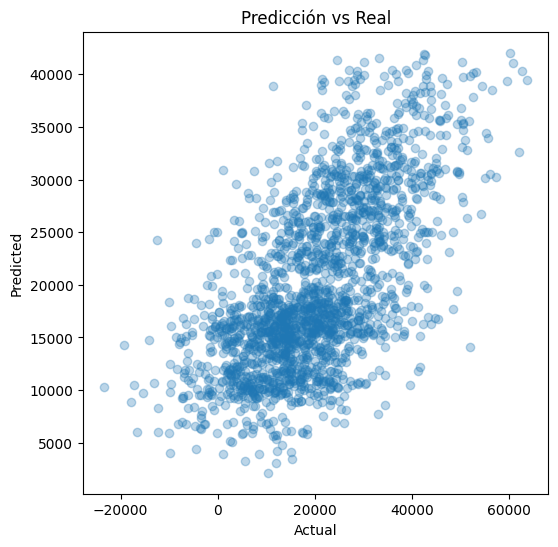

In [20]:
#Predicciones vs Real
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicción vs Real")
plt.show()


## Visualización Interactiva

In [21]:

df_plot = df.copy()
df_plot["age_group"] = pd.cut(df_plot["age"], bins=5)

fig = px.scatter(df_plot,
                 x="age",
                 y="claims_amount",
                 color="policy_type",
                 animation_frame="region",
                 title="Costos de Siniestros por Región y Tipo de Póliza")

fig.show()
